# 7. Графы

### 7.1 Поиск в ширину

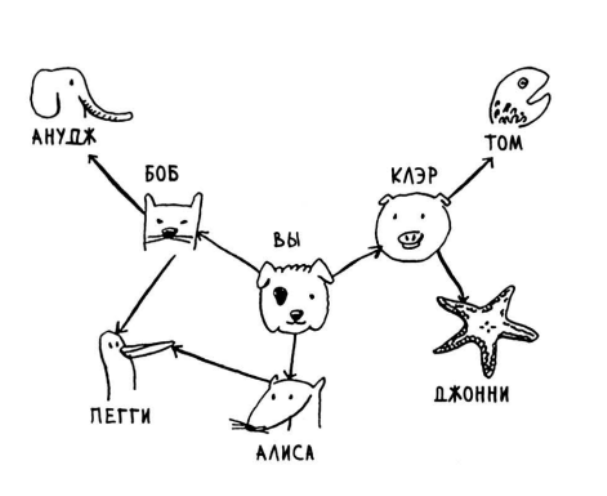

In [11]:
from collections import deque

def is_mango_seller(name):
    return name[-1] == 'м'

graph = {
    'вы': ['Алиса', 'Клэр', 'Боб'],
    'Боб': ['Анудж', 'Пегги'],
    'Алиса': ['Пегги'],
    'Клэр': ['Джонни', 'Том'],
    'Анудж': [],
    'Пегги': [],
    'Джонни': [],
    'Том': []
}

def bfs_mango(name):
    search_qeu = deque()
    search_qeu += graph[name]
    searched = []

    while search_qeu:
        person = search_qeu.popleft()
        if person not in searched:
            if is_mango_seller(person):
                print(f'Манго продает {person}')
                return True
            else:
                search_qeu += graph.get(person, [])
                searched.append(person)
                print(f'Просмотрены: {searched}')
    print('Никто не торгует этим вашим манго')
    return False

bfs_mango('вы')


Просмотрены: ['Алиса']
Просмотрены: ['Алиса', 'Клэр']
Просмотрены: ['Алиса', 'Клэр', 'Боб']
Просмотрены: ['Алиса', 'Клэр', 'Боб', 'Пегги']
Просмотрены: ['Алиса', 'Клэр', 'Боб', 'Пегги', 'Джонни']
Манго продает Том


True

### 7.2 Алгоритм Дейкстры

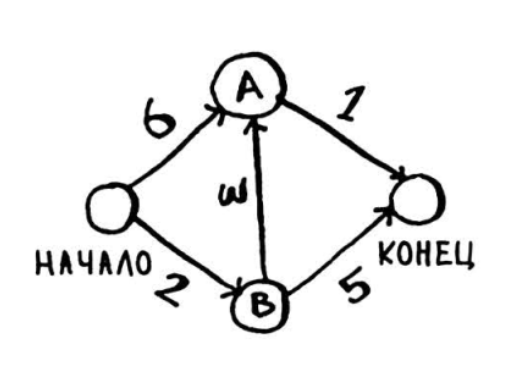

In [19]:
graph = {
    'начало': {'a': 6, 'b': 2},
    'a': {'конец': 1},
    'b': {'a': 3, 'конец': 5},
    'конец': {}
}

infinity = float('inf')
costs = {'a': 6, 'b': 5, 'конец': infinity}
parents = {'a': 'начало', 'b':'начало', 'конец': None}
processed = []

def find_min_cost(costs):
    minimum = float('inf')
    min_cost_node = None
    for node in costs:
        cost = costs[node]
        if cost < minimum and node not in processed:
            minimum = cost
            min_cost_node = node
    return min_cost_node

node = find_min_cost(costs)

while node:
    cost = costs[node]
    neighbours = graph[node]
    for n in neighbours:
        new_cost = cost + neighbours[n]
        if costs[n] > new_cost:
            costs[n] = new_cost
            parents[n] = node
    processed.append(node)
    node = find_min_cost(costs)

print('Наименьшая стоимость:', costs)
print('Родители:', parents)

Наименьшая стоимость: {'a': 6, 'b': 5, 'конец': 7}
Родители: {'a': 'начало', 'b': 'начало', 'конец': 'a'}


# Задание
### 1. Поиск в ширину
Смоделируйте сеть городов. Найдите кратчайшее количество пересадок между городом А и городом Е. Реализуйте BFS.

### 2. Алгоритм Дейкстры

Создайте граф доставки товаров между складами. Укажите расстояния. Найдите кратчайший путь доставки от главного склада до всех точек.

### *3. Сравнение

Придумайте граф, где BFS даст не оптимальный путь (по весу), а Дейкстра — даст. Напишите обе реализации и сравните результат.

In [13]:
from collections import deque

cities = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

def bfs(start, end):
    visited = []
    que = deque([[start]])

    if start == end:
        return [start]
    
    while que:
        path = que.popleft()
        node = path[-1]

        if node not in visited:
            neighbours = cities[node]
            for neighbor in neighbours:
                new = list(path)
                new.append(neighbor)
                que.append(new)

            if neighbor == end:
                return new
            visited.append(node)
    if start or end not in cities:
        print(f'Такого города нет!')
    return None


In [15]:
start = 'A'
end = 'E'
fun = bfs(start, end)
print(f'Кратчайшее кол-во пересадок {len(fun)-1}')

Кратчайшее кол-во пересадок 2


In [25]:
import heapq
warehouses = {
    'Main': {'A': 4, 'B': 2},
    'A': {'Main': 4, 'C': 3},
    'B': {'Main': 2, 'C': 5, 'D': 1},
    'C': {'A': 3, 'B': 5, 'D': 2},
    'D': {'B': 1, 'C': 2}
}

def djkstra(graph, start):
    dist = {node: float('inf') for node in graph}
    dist[start] = 0
    prior_que = [(0,start)]

    while prior_que:
        current_dist, current_node = heapq.heappop(prior_que)

        if current_dist > dist[current_node]:
            continue

        for a,b in graph[current_node].items():
            distance = current_dist+b
            if distance < dist[a]:
                dist[a]=distance
                heapq.heappush(prior_que, (distance, a))
    return dist

In [27]:
start = "Main"
short = djkstra(warehouses, start)
print(short)


{'Main': 0, 'A': 4, 'B': 2, 'C': 5, 'D': 3}


In [28]:
graph = {
    'A': {'B': 1, 'C': 3},
    'B': {'C': 2},
    'C': {}
}

In [ ]:
start = 'A'
end = 'C'
print(bfs(start, end))
print(djkstra(graph,start))

['A', 'C']
{'A': 0, 'B': 1, 'C': 3}


#### Видим, что bfs дает не оптимальный оп весу путь, в отличие от алгоритма дейктсры, который дает более длительный путь, но оптимальный по весу путь